<a href="https://colab.research.google.com/github/GutierreOliveira91/Projeto_Pandas/blob/main/Projeto_EmendasParlamentares_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Arquivo carregado com sucesso!
O dataset tem 3762 linhas e 19 colunas.

--- Primeiras linhas do arquivo ---


,Ano,Tipo de Emenda,Autor da emenda,Número da emenda,Possui Apoiador/Solicitante?,Localidade do gasto (Regionalização),Função,Subfunção,Programa Orçamentário,Ação Orçamentária,Plano Orçamentário,Código da emenda,Valor empenhado,Valor liquidado,Valor pago,Valor Restos a Pagar Inscritos,Valor Restos a Pagar Cancelados,Valor Restos a Pagar Pagos,Unnamed: 18
0,2026,Emenda Individual - Transferências com Finalid...,4451 - PROFESSORA LUCIENE CAVALCANTE,9,Não se aplica,SÃO PAULO (UF),Educação,Ensino profissional,5112 - EDUCACAO PROFISSIONAL E TECNOLOGICA QUE...,20RG - REESTRUTURACAO E MODERNIZACAO DAS INSTI...,REESTRUTURACAO E MODERNIZACAO DAS INSTITUICOES...,202644510009,"- 132.195,00","0,00","0,00","0,00","0,00","0,00",NaN
1,2026,Emenda Individual - Transferências com Finalid...,4366 - DUDA SALABERT,17,Não se aplica,Nacional,Defesa nacional,Desenvolvimento científico,"6113 - OCEANO, ZONA COSTEIRA E ANTARTICA",2345 - APOIO LOGISTICO A PESQUISA CIENTIFICA N...,APOIO LOGISTICO A PESQUISA CIENTIFICA NA ANTAR...,202643660017,"108,85","108,85","108,85","0,00","0,00","0,00",NaN
2,2026,Emenda Individual - Transferências com Finalid...,2764 - PADRE JOAO,6,Não se aplica,MINAS GERAIS (UF),Educação,Ensino superior,"5113 - EDUCACAO SUPERIOR: QUALIDADE, DEMOCRACI...","20GK - FOMENTO AS ACOES DE GRADUACAO, POS-GRAD...","FOMENTO AS ACOES DE GRADUACAO, POS-GRADUACAO, ...",202627640006,"142,64","0,00","0,00","0,00","0,00","0,00",NaN
3,2026,Emenda Individual - Transferências com Finalid...,4064 - ROGERIO CORREIA,2,Não se aplica,BELO HORIZONTE - MG,Educação,Ensino superior,"5113 - EDUCACAO SUPERIOR: QUALIDADE, DEMOCRACI...","20GK - FOMENTO AS ACOES DE GRADUACAO, POS-GRAD...","FOMENTO AS ACOES DE GRADUACAO, POS-GRADUACAO, ...",202640640002,"142,64","0,00","0,00","0,00","0,00","0,00",NaN
4,2026,Emenda Individual - Transferências com Finalid...,4553 - LENIR DE ASSIS,21,Não se aplica,Nacional,Educação,Ensino superior,"5113 - EDUCACAO SUPERIOR: QUALIDADE, DEMOCRACI...","20GK - FOMENTO AS ACOES DE GRADUACAO, POS-GRAD...","FOMENTO AS ACOES DE GRADUACAO, POS-GRADUACAO, ...",202645530021,"272,40","0,00","0,00","0,00","0,00","0,00",NaN



--- Resumo das colunas ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3762 entries, 0 to 3761
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Ano                                   3762 non-null   int64  
 1   Tipo de Emenda                        3762 non-null   object 
 2   Autor da emenda                       3762 non-null   object 
 3   Número da emenda                      3762 non-null   int64  
 4   Possui Apoiador/Solicitante?          3762 non-null   object 
 5   Localidade do gasto (Regionalização)  3762 non-null   object 
 6   Função                                3762 non-null   object 
 7   Subfunção                             3762 non-null   object 
 8   Programa Orçamentário                 3762 non-null   object 
 9   Ação Orçamentária                     3762 non-null   object 
 10  Plano Orçamentário                    3762 non-null   ob

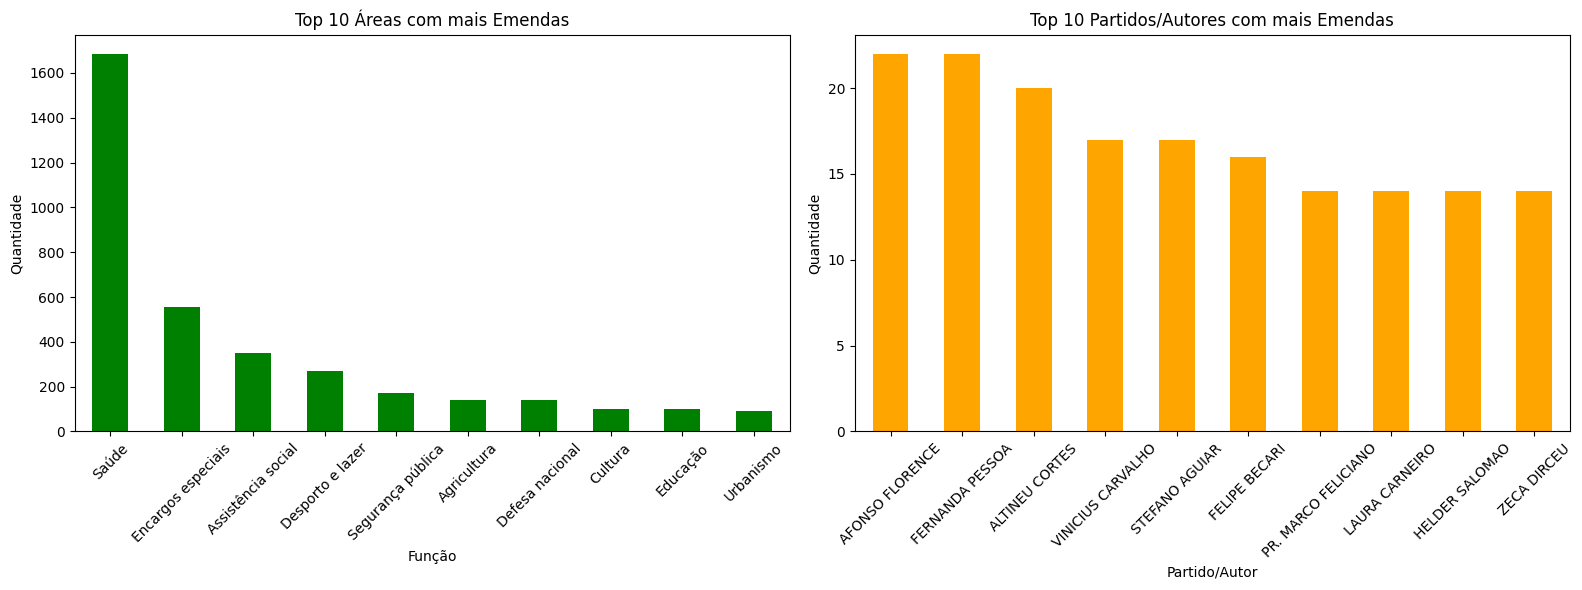


--- Fim do Processo ---
1. O arquivo 'emendas_limpas.csv' foi gerado com sucesso.


In [1]:
# ==========================================================
# TRABALHO DE PANDAS - ANÁLISE DE EMENDAS PARLAMENTARES 2026
# ============= André, Gutierre e Natham ===================
# ==========================================================

# Etapa 0: Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Etapa 1: Ler os dados do GitHub
# ----------------------------------------------------------
url = "https://raw.githubusercontent.com/GutierreOliveira91/Projeto_Pandas/main/emendas.csv"

df = pd.read_csv(url, sep=";", encoding="utf-8" )

print("Arquivo carregado com sucesso!")
print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas.")

# ----------------------------------------------------------
# Etapa 2: Consulta
# ----------------------------------------------------------
print("\n--- Primeiras linhas do arquivo ---")
display(df.head())

print("\n--- Resumo das colunas ---")
df.info()

# ----------------------------------------------------------
# Etapa 3: Limpeza dos dados
# ----------------------------------------------------------
df_limpo = df.copy()

# 1. Remover colunas totalmente vazias
colunas_vazias = [col for col in df_limpo.columns if df_limpo[col].isnull().all()]
df_limpo = df_limpo.drop(columns=colunas_vazias)

# 2. Tirar linhas duplicadas
df_limpo = df_limpo.drop_duplicates()

# 3. Tratar valores nulos
df_limpo = df_limpo.fillna('Não Informado')

# 4. Ajustar os valores de dinheiro
colunas_valor = ['Valor empenhado', 'Valor liquidado', 'Valor pago']
for col in colunas_valor:
    if col in df_limpo.columns:
        df_limpo[col] = df_limpo[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        df_limpo[col] = pd.to_numeric(df_limpo[col], errors='coerce').fillna(0)

# 5. Criar uma coluna só para o PARTIDO (tentando extrair do nome do autor)
df_limpo['Partido/Autor'] = df_limpo['Autor da emenda'].apply(lambda x: str(x).split(' - ')[-1])

print("\nLimpeza finalizada!")

# ----------------------------------------------------------
# Etapa 4: Gerar Gráficos
# ----------------------------------------------------------
print("\nGerando gráficos de análise...")

# Criando dois gráficos lado a lado para ficar bem completo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Áreas (Função)
df_limpo['Função'].value_counts().head(10).plot(kind='bar', color='green', ax=ax1)
ax1.set_title('Top 10 Áreas com mais Emendas')
ax1.set_ylabel('Quantidade')
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Partidos/Autores
df_limpo['Partido/Autor'].value_counts().head(10).plot(kind='bar', color='orange', ax=ax2)
ax2.set_title('Top 10 Partidos/Autores com mais Emendas')
ax2.set_ylabel('Quantidade')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Etapa 5: Salvar o novo arquivo CSV
# ----------------------------------------------------------
nome_arquivo = "emendas_limpas.csv"
df_limpo.to_csv(nome_arquivo, index=False)

print(f"\n--- Fim do Processo ---")
print(f"1. O arquivo '{nome_arquivo}' foi gerado com sucesso.")